In [19]:
from typing import Any

from kirin.ir import Method
import matplotlib.pyplot as plt
import numpy as np

from bloqade import squin, tsim
from bloqade.cirq_utils import emit_circuit, load_circuit, noise
from bloqade.pyqrack import StackMemorySimulator
from bloqade.types import MeasurementResult, Qubit
from kirin.dialects.ilist import IList
import matplotlib.pyplot as plt


In [20]:
Register = IList[Qubit, Any]
Measurement = IList[MeasurementResult, Any]

def show_circuit(squin_kernel):
    @squin.kernel
    def _to_visualize():
        _ = squin_kernel()

    return tsim.Circuit(_to_visualize).diagram(height=400)

In [21]:
@squin.kernel
def t_inj_prep() -> Register:
    qubits = squin.qalloc(1)
    squin.h(qubits[0])
    squin.t(qubits[0])
    return qubits

In [22]:

def dataState(gates: str) -> Register:
    gates = [g for g in gates.upper() if g in 'HSTX']
    
    @squin.kernel
    def dataPrep() -> Register:
        data = squin.qalloc(1)
        
        for gate in gates:
            if gate == 'H':
                squin.h(data[0])
            elif gate == 'S':
                squin.s(data[0])
            elif gate == 'T':
                ancillaT = t_inj_prep()
                squin.cx(data[0], ancillaT[0])
                if squin.measure(ancillaT[0]) == 1:
                    squin.s(data[0])
            elif gate == 'X':
                squin.h(data[0])
                squin.s(data[0])
                squin.s(data[0])
                squin.h(data[0])
        return data
    return dataPrep

In [23]:
# @squin.kernel
# def encode() -> Register:
#     qubits = squin.qalloc(7)
#     squin.h(qubits[0])
#     squin.cx(qubits[0],qubits[3])
#     squin.cx(qubits[0],qubits[5])
#     squin.cx(qubits[0],qubits[6])
#     squin.h(qubits[1])
#     squin.cx(qubits[1],qubits[3])
#     squin.cx(qubits[1],qubits[4])
#     squin.cx(qubits[1],qubits[6])
#     squin.h(qubits[2])
#     squin.cx(qubits[2],qubits[3])
#     squin.cx(qubits[2],qubits[4])
#     squin.cx(qubits[2],qubits[5])
#     return qubits

In [24]:


def steaneEncoding(gates: str):
    @squin.kernel
    def encodingKernel():
        dataQubit = dataState(gates)()
        physicalQubits = squin.qalloc(6)

        squin.h(physicalQubits[3])
        squin.h(physicalQubits[4])
        squin.h(physicalQubits[5])
        
        squin.cx(dataQubit[0], physicalQubits[0])
        squin.cx(dataQubit[0], physicalQubits[1])

        squin.cx(physicalQubits[5], dataQubit[0])
        squin.cx(physicalQubits[5], physicalQubits[0])
        squin.cx(physicalQubits[5], physicalQubits[2])
        
        squin.cx(physicalQubits[4], dataQubit[0])
        squin.cx(physicalQubits[4], physicalQubits[1])
        squin.cx(physicalQubits[4], physicalQubits[2])

        squin.cx(physicalQubits[3], physicalQubits[0])
        squin.cx(physicalQubits[3], physicalQubits[1])
        squin.cx(physicalQubits[3], physicalQubits[2])
        return dataQubit + physicalQubits

    return encodingKernel

In [25]:
#show_circuit(steaneEncoding('HSSH'))

In [26]:
# T cannot be implemented transversally, teleporting in on every qubit does not fix the irretransversality of T.

# Injecting T gate transversally via magic state injection
# def t_injectionLogical(logicalQubit):
#     @squin.kernel
#     def t_injection_kernel() -> Register:
#         for qubit in logicalQubit:
#             a_register = t_inj_prep()
#             squin.cx(qubit, a_register[0])
#             mid_circuit_measurement = squin.broadcast.measure([a_register[0]])
#             if mid_circuit_measurement[0] == 1:
#                 squin.s(qubit)
#         return logicalQubit
#     return t_injection_kernel

# Logical Qubit - 7 qubits, loop each apply T on each

In [27]:
def steaneMeasure(gates: str = ''):
    @squin.kernel
    def steaneMeasureKernel() -> Register:
        dataQubit = dataState(gates)()
        physicalQubits = squin.qalloc(6)

        squin.h(physicalQubits[3])
        squin.h(physicalQubits[4])
        squin.h(physicalQubits[5])
        
        squin.cx(dataQubit[0], physicalQubits[0])
        squin.cx(dataQubit[0], physicalQubits[1])

        squin.cx(physicalQubits[5], dataQubit[0])
        squin.cx(physicalQubits[5], physicalQubits[0])
        squin.cx(physicalQubits[5], physicalQubits[2])
        
        squin.cx(physicalQubits[4], dataQubit[0])
        squin.cx(physicalQubits[4], physicalQubits[1])
        squin.cx(physicalQubits[4], physicalQubits[2])

        squin.cx(physicalQubits[3], physicalQubits[0])
        squin.cx(physicalQubits[3], physicalQubits[1])
        squin.cx(physicalQubits[3], physicalQubits[2])

        bits = squin.broadcast.measure([dataQubit[0]])
        bits = bits + squin.broadcast.measure(physicalQubits)
        return bits
    return steaneMeasureKernel

# Simulate the encode circuit using PyQrack
# @squin.kernel
# def encode_and_measure() -> Measurement:
#     qubits = squin.qalloc(7)
#     squin.h(qubits[0])
#     squin.cx(qubits[0],qubits[3])
#     squin.cx(qubits[0],qubits[5])
#     squin.cx(qubits[0],qubits[6])
#     squin.h(qubits[1])
#     squin.cx(qubits[1],qubits[3])
#     squin.cx(qubits[1],qubits[4])
#     squin.cx(qubits[1],qubits[6])
#     squin.h(qubits[2])
#     squin.cx(qubits[2],qubits[3])
#     squin.cx(qubits[2],qubits[4])
#     squin.cx(qubits[2],qubits[5])
#     bits = squin.broadcast.measure(qubits)
#     return bits

from collections import Counter

simulator = StackMemorySimulator(min_qubits=7)
kernel_method = steaneMeasure('X')
task = simulator.task(kernel_method)

shots = 1024
counts = Counter()
for _ in range(shots):
    result = task.run()
    bitstring = ''.join(str(int(b)) for b in result)
    counts[bitstring] += 1

print(f'Measurement outcomes over {shots} shots:')
print(f'  {"Bitstring":<15} {"Count":<8} Frequency')
for bs, cnt in sorted(counts.items(), key=lambda x: -x[1]):
    print(f'  {bs:<15} {cnt:<8} {cnt/shots:.3f}')
print(f'\nUnique outcomes: {len(counts)} (expected 8 for |0_L>)')

kernel_method = steaneMeasure()
task = simulator.task(kernel_method)

shots = 1024
counts = Counter()
for _ in range(shots):
    result = task.run()
    bitstring = ''.join(str(int(b)) for b in result)
    counts[bitstring] += 1

print(f'Measurement outcomes over {shots} shots:')
print(f'  {"Bitstring":<15} {"Count":<8} Frequency')
for bs, cnt in sorted(counts.items(), key=lambda x: -x[1]):
    print(f'  {bs:<15} {cnt:<8} {cnt/shots:.3f}')
print(f'\nUnique outcomes: {len(counts)} (expected 8 for |0_L>)')

Measurement outcomes over 1024 shots:
  Bitstring       Count    Frequency
  1001100         139      0.136
  1000011         137      0.134
  0100101         133      0.130
  0011001         132      0.129
  1111111         131      0.128
  0010110         124      0.121
  0101010         118      0.115
  1110000         110      0.107

Unique outcomes: 8 (expected 8 for |0_L>)
Measurement outcomes over 1024 shots:
  Bitstring       Count    Frequency
  1011010         141      0.138
  0000000         139      0.136
  1100110         131      0.128
  1010101         126      0.123
  0001111         126      0.123
  0110011         123      0.120
  0111100         123      0.120
  1101001         115      0.112

Unique outcomes: 8 (expected 8 for |0_L>)


In [28]:
#show_circuit(t_injectionLogical(steaneEncoding('HSSH')))

### PyQrack Simulation of T Injection

The subroutine return values (`encode()`, `t_inj_prep()`) cause an `IList` unpacking issue inside the PyQrack task runner, so the full circuit is inlined here for simulation.

In [29]:
# Full T-injection circuit inlined for PyQrack simulation
@squin.kernel
def t_injection_and_measure() -> Measurement:
    # --- encode logical |0_L> ---
    qubits = squin.qalloc(7)
    squin.h(qubits[0])
    squin.cx(qubits[0],qubits[3])
    squin.cx(qubits[0],qubits[5])
    squin.cx(qubits[0],qubits[6])
    squin.h(qubits[1])
    squin.cx(qubits[1],qubits[3])
    squin.cx(qubits[1],qubits[4])
    squin.cx(qubits[1],qubits[6])
    squin.h(qubits[2])
    squin.cx(qubits[2],qubits[3])
    squin.cx(qubits[2],qubits[4])
    squin.cx(qubits[2],qubits[5])
    # --- T injection on each physical qubit ---

    anc0 = squin.qalloc(1)
    squin.h(anc0[0]); squin.t(anc0[0])
    squin.cx(qubits[0], anc0[0])
    m0 = squin.broadcast.measure([anc0[0]])
    if m0[0]: squin.s(qubits[0])
    anc1 = squin.qalloc(1)
    squin.h(anc1[0]); squin.t(anc1[0])
    squin.cx(qubits[1], anc1[0])
    m1 = squin.broadcast.measure([anc1[0]])
    if m1[0]: squin.s(qubits[1])
    anc2 = squin.qalloc(1)
    squin.h(anc2[0]); squin.t(anc2[0])
    squin.cx(qubits[2], anc2[0])
    m2 = squin.broadcast.measure([anc2[0]])
    if m2[0]: squin.s(qubits[2])
    anc3 = squin.qalloc(1)
    squin.h(anc3[0]); squin.t(anc3[0])
    squin.cx(qubits[3], anc3[0])
    m3 = squin.broadcast.measure([anc3[0]])
    if m3[0]: squin.s(qubits[3])
    anc4 = squin.qalloc(1)
    squin.h(anc4[0]); squin.t(anc4[0])
    squin.cx(qubits[4], anc4[0])
    m4 = squin.broadcast.measure([anc4[0]])
    if m4[0]: squin.s(qubits[4])
    anc5 = squin.qalloc(1)
    squin.h(anc5[0]); squin.t(anc5[0])
    squin.cx(qubits[5], anc5[0])
    m5 = squin.broadcast.measure([anc5[0]])
    if m5[0]: squin.s(qubits[5])
    anc6 = squin.qalloc(1)
    squin.h(anc6[0]); squin.t(anc6[0])
    squin.cx(qubits[6], anc6[0])
    m6 = squin.broadcast.measure([anc6[0]])
    if m6[0]: squin.s(qubits[6])
    # --- measure logical qubit ---
    bits = squin.broadcast.measure(qubits)
    return bits
    

from collections import Counter

simulator = StackMemorySimulator(min_qubits=14)  # 7 data + 7 ancilla
task = simulator.task(t_injection_and_measure)

shots = 1024
counts = Counter()
for _ in range(shots):
    result = task.run()
    bitstring = ''.join(str(int(b)) for b in result)
    counts[bitstring] += 1

print(f'T-injection outcomes over {shots} shots:')
print(f'  {"Bitstring":<15} {"Count":<8} Frequency')
for bs, cnt in sorted(counts.items(), key=lambda x: -x[1]):
    print(f'  {bs:<15} {cnt:<8} {cnt/shots:.3f}')
print(f'\nUnique outcomes: {len(counts)}')
print('Expected: 8 codewords of T|0_L> = |0_L> (T gate on |0> gives |0> up to phase)')

T-injection outcomes over 1024 shots:
  Bitstring       Count    Frequency
  0000000         147      0.144
  0101101         142      0.139
  0110011         135      0.132
  1010101         131      0.128
  1100110         119      0.116
  1111000         118      0.115
  0011110         117      0.114
  1001011         115      0.112

Unique outcomes: 8
Expected: 8 codewords of T|0_L> = |0_L> (T gate on |0> gives |0> up to phase)


Verifying the family of Rz Rotations on the Logical Qubit. Since Z and S are clifford gates, they are transversal in the Steane code, meaning we can apply them directly to each physical qubit of the logical qubit.

##### Initialize Logical Qubit to |+_L> then apply Z Gate, S Gate, T Gate Injection, and GridSynth for z rotation family.
##### For each, apply gate, then compare each overlap to ideal gate application density matrix i.e. no need for ancillas.
##### 1. Create Logical 2. Loop through qubits and apply gate 3. Run task and extract density matrix 4. Compare to ideal density matrix for each gate application


In [30]:
# S and H Gates are a part of the Clifford Group, and thus can be applied transversally over the Steane code.
# The T gate though is a non-Clifford gate, and thus cannot be applied transversally. Instead, we will implement it using a teleportation-based approach, which involves preparing an ancilla in the appropriate state and performing a joint operation with the data qubits.

# S Gate
# @squin.kernel
# def applySLogical(logicalQubit) -> Register:
#     squin.broadcast.s(logicalQubit)
#     return logicalQubit

# # H Gate Application
# @squin.kernel
# def applyHLogical(logicalQubit) -> Register:
#     squin.broadcast.h(logicalQubit)
#     return logicalQubit

# @squin.kernel
# def applyCXLogical(controlLogicalQubit: Register, targetLogicalQubit: Register) -> Register:
#     squin.broadcast.cx(controlLogicalQubit, targetLogicalQubit)
#     return controlLogicalQubit, targetLogicalQubit

In [31]:
# GridSynth Methods
import subprocess

def run_gridsynth(angle, random_seed=40) -> str:
    """
    Run gridsynth and return the output string.
    
    Args:
        angle: Angle expression as string (e.g., "pi/4", "-2*pi/7")
    
    Returns:
        Gridsynth output string
    """
    result = subprocess.run(
        [r"C:\cabal\bin\gridsynth.exe", angle, f"-r {random_seed}"],
        capture_output=True,
        text=True
    )
    return result.stdout.strip()

def run_gridsynth(angle, options=["--phase"]) -> str:
    """
    Run gridsynth and return the output string.
    
    Args:
        angle: Angle expression as string (e.g., "pi/4", "-2*pi/7")
        options: List of option strings (e.g., ["-d", "100"])
    
    Returns:
        Gridsynth output string
    """
    cmd = [r"C:\cabal\bin\gridsynth.exe"]
    if options:
        cmd.extend(options)
    cmd.append(angle)
    
    result = subprocess.run(cmd, capture_output=True, text=True)
    return result.stdout.strip()

In [32]:
# Resource Tracking
ideal_rotation_resources = {
    'ancilla count': 0,
    '2-qubit gate count': 0,
    'circuit depth': 0,
    # 'repeated trials': 0, # TODO: not sure what this is supposed to measure
    'feed-forward operations': 0
}

with_injection_resources = {
    'ancilla count': 1, # constant since we reuse the ancilla for each T gate
    '2-qubit gate count': 0,
    'circuit depth': 0,
    # 'repeated trials': 0,
    'feed-forward operations': 0
}

In [33]:

def idealLogicalQubit(gridsynth_output: str):
    gate_sequence = [g for g in reversed(gridsynth_output.upper()) if g != 'W']
    return steaneEncoding('H'+''.join(gate_sequence))

In [16]:
def getLogicalCircuitWithInjection(gridsynth_output: str):
    gate_sequence = [g for g in reversed(gridsynth_output.upper()) if g != 'W']

    @squin.kernel
    def circuitKernel():
        logicalQubit = steaneEncoding('H')() # Initialize logical qubit in |+_L> state

        for gate in gate_sequence:
            if gate == 'T':
                ancillaLogical = steaneEncoding('HT')()
                squin.broadcast.cx(logicalQubit, ancillaLogical)
                measurement = squin.broadcast.measure(ancillaLogical)  # mid-circuit measurement

                with_injection_resources['2-qubit gate count'] += 7
                with_injection_resources['circuit depth'] += 1

                for i in range(7):
                    if measurement[i] == 1:
                        squin.s(logicalQubit[i])  # Apply S correction to the corresponding data qubit
                        with_injection_resources['feed-forward operations'] += 1
                        with_injection_resources['circuit depth'] += 1
                        squin.x(logicalQubit[i])  # Apply X correction to the corresponding data qubit

            elif gate == 'S':
                squin.broadcast.s(logicalQubit)
                with_injection_resources['circuit depth'] += 1
            elif gate == 'H':
                squin.broadcast.h(logicalQubit)
                with_injection_resources['circuit depth'] += 1
            elif gate == 'X':
                squin.broadcast.h(logicalQubit)
                squin.broadcast.s(logicalQubit)
                squin.broadcast.s(logicalQubit)
                squin.broadcast.h(logicalQubit)
                with_injection_resources['circuit depth'] += 4
        return logicalQubit
    return circuitKernel

In [35]:
# gate_string = run_gridsynth("pi/8")
# gate_string += 'H' # added so that the effect of rotation is noticable

# simulator = StackMemorySimulator(min_qubits=8)
# rho_task = simulator.task(getLogicalCircuitWithInjection(gate_string))
# rho_state = task.run()
# rhoInjection = StackMemorySimulator.reduced_density_matrix([rho_task.qubits()[0]])
# print(rhoInjection)

# psi_simulator = StackMemorySimulator(min_qubits=7)
# psi_task = psi_simulator.task(getLogicalCircuitIdeal(gate_string))
# psi_state = psi_task.run()  
# rhoIdeal = StackMemorySimulator.reduced_density_matrix([psi_task.qubits()[0]])
# print(rhoIdeal)

In [18]:
overlaps = []

for n in range(10):
    print(f"Trial for n={n}:")
    gate_string = 'H' + ''.join(run_gridsynth(f"pi/{2**n}"))
    # added so that the effect of rotation is noticable

    t_count = gate_string.upper().count('T')
    total_qubits = 7 + 7 * t_count
    
    simulator = StackMemorySimulator(min_qubits = total_qubits)
    injectionKernel = getLogicalCircuitWithInjection(gate_string)
    task = simulator.task(injectionKernel)
    task.run()
    rhoInjection =StackMemorySimulator.reduced_density_matrix([task.qubits()[0]])

    psi_simulator = StackMemorySimulator(min_qubits=7)
    ideal_kernel = idealLogicalQubit(gate_string)
    psi_task = psi_simulator.task(ideal_kernel)
    psi_task.run()
    psiIdeal = StackMemorySimulator.reduced_density_matrix([psi_task.qubits()[0]])
    
    overlaps.append(np.real(np.trace(psiIdeal @ rhoInjection)))

    print(psiIdeal, rhoInjection)

    print("States match?:", np.allclose(psiIdeal, rhoInjection, atol = 1e-5))

Trial for n=0:
[[0.49999998+0.j 0.        +0.j]
 [0.        +0.j 0.49999998+0.j]] [[0.49999978+0.j 0.        +0.j]
 [0.        +0.j 0.49999978+0.j]]
States match?: True
Trial for n=1:
[[0.4999998+0.j 0.       +0.j]
 [0.       +0.j 0.4999998+0.j]] [[0.49999977+0.j 0.        +0.j]
 [0.        +0.j 0.49999977+0.j]]
States match?: True
Trial for n=2:
[[0.4999999+0.j 0.       +0.j]
 [0.       +0.j 0.4999999+0.j]] [[0.50000013+0.j 0.        +0.j]
 [0.        +0.j 0.50000013+0.j]]
States match?: True
Trial for n=3:


OSError: exception: access violation reading 0x0000000000000000

In [ ]:
infidelity = np.abs(1 - np.array(overlaps))

ValueError: x and y must have same first dimension, but have shapes (10,) and (3,)

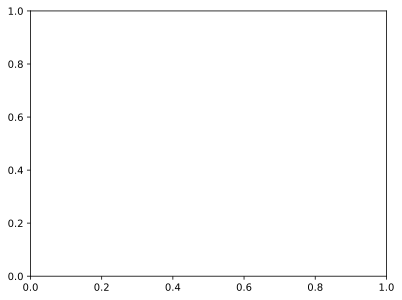

In [ ]:
plt.plot(range(10), infidelity, marker='o')
plt.xlabel("n (for rotation angle $\\pi/2^n$ radians)")
plt.ylabel("Infidelity ")
plt.title("Infidelity of Feed-Forward Ancilla Circuit vs No-Ancilla Circuit")
plt.xticks(range(10))
plt.savefig("Figures/infidelity_plot.png", dpi=300, bbox_inches='tight')